# The Transformation and Accept/Reject (aka. Von Neumann) methods

Python notebook for illustrating how to generate random numbers following a specific PDF using uniformly distributed random numbers. Both the Accept-Reject (Von Neumann) and transformation methods are used.

### References:
- G. Cowan: Chapter 3
- P. R. Bevington: page 81-84
- __[40. Monte Carlo Techniques PDG](https://pdg.lbl.gov/2023/reviews/rpp2023-rev-monte-carlo-techniques.pdf)__

### Authors: 
- Troels C. Petersen (Niels Bohr Institute)
- Peter Resch

### Date:    
- 2.12.2025

***

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit, cost
from scipy import stats
plt.rcParams['font.size'] = 18

In [2]:
r = np.random
r.seed(42)

save_plots = False   
N_points = 10000      # Number of random points to be produced!

xmin = 0.0
xmax = 1.0
N_bins = 100

# Define f(x) = 2x, for x in [0,1]
def fx_2x(x) :
    # Normalization is N_points * binwidth:
    k = (xmax - xmin) / N_bins
    N = N_points * k
    return N * 2*x

### TRANSFORMATION METHOD - random points following $f(x) = 2x, x \in [0, 1]$.

To produce random numbers according to $f(x)$ we use the transformation method:

$F(x) = x^2$ and then $F^{-1}(r) = \sqrt{r}$, where $r$ is uniform numbers in $[0,1]$

In [3]:
x_transformation = np.sqrt(r.uniform(size=N_points))

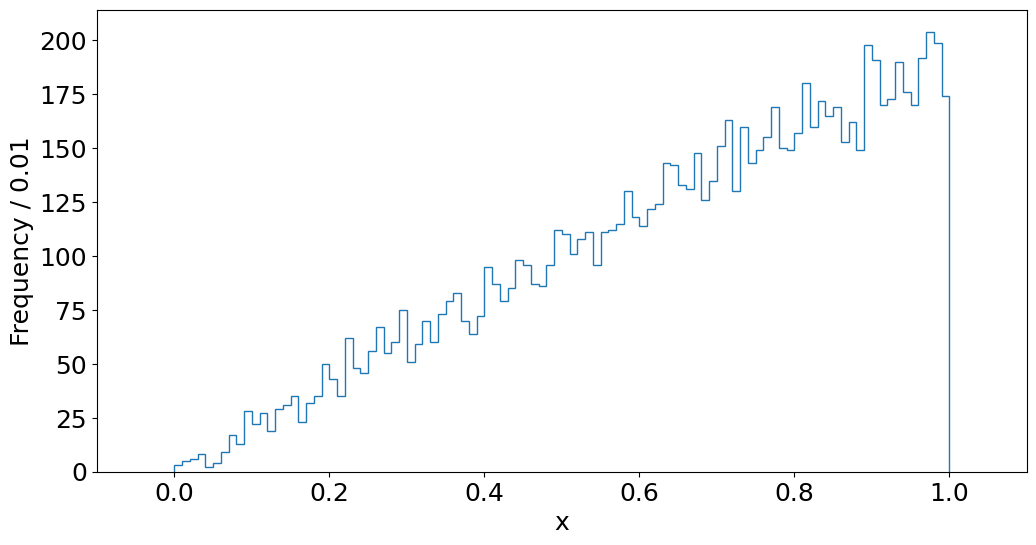

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(x_transformation, bins=N_bins, range=(xmin, xmax), histtype='step', label='histogram' )
ax.set(xlabel="x", ylabel="Frequency / 0.01", xlim=(xmin-0.1, xmax+0.1));

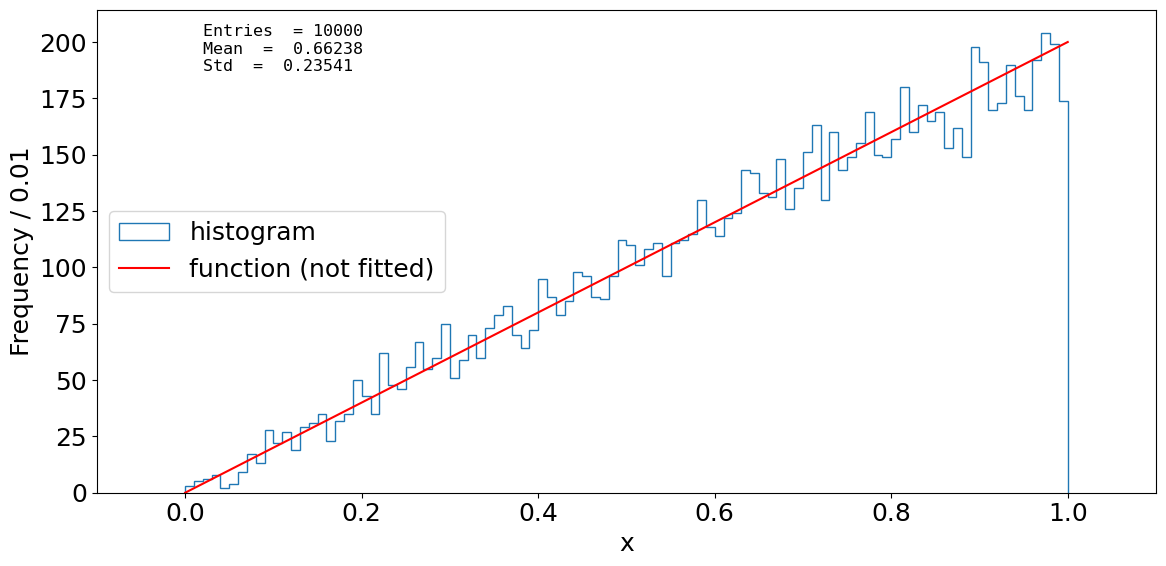

In [5]:
# Plot f(x)
x_axis1 = np.linspace(xmin, xmax, 1000)
y_axis1 = fx_2x(x_axis1)
ax.plot(x_axis1, y_axis1, 'r-', label='function (not fitted)')

# Define figure text
plot_info = ['Entries  = ' + f"{len(x_transformation)}",
     'Mean  =  ' + f"{x_transformation.mean():3.5f}",
     'Std  =  '+ f"{x_transformation.std(ddof=1):3.5f}",
]

# Plot figure text
ax.text(0.1, 0.97, "\n".join(plot_info), family='monospace', fontsize=12, verticalalignment='top',transform=ax.transAxes)

# Add legend
ax.legend(loc='best')
fig.tight_layout()

# Save figure
if save_plots: 
    fig.savefig("Hist_2x_TransformationMethod.pdf", dpi=600)

# Show the figure
fig

### ACCEPT/REJECT METHOD - random points following $f(x) = 2x, x \in [0, 1]$.

In [6]:
N_try = 0
ymin = 0.0      # Minimum value the function will take!
ymax = 2.0      # Maximum value the function will take!
x_accepted = np.zeros(N_points)

for i in range(N_points):
    
    while True:
        # Count the number of tries, to get efficiency/integral
        N_try += 1                    
        
        # Range that f(x) is defined/wanted in:
        x_rand = r.uniform(xmin, xmax)  
        
        # Upper bound for function values:
        y_rand = r.uniform(ymin, ymax)
        
        if (y_rand < 2 * x_rand):
            break
            
    x_accepted[i] = x_rand

The Accept/Reject method is not $100%$ perfective, meaning that to generate $N$ random points according to $f(x)$ we have to loop $M > N$ times. Here the efficiency is defined as $\epsilon = N / M = $ `eff`:

In [7]:
# Efficiency
eff = N_points / N_try                        

# Error on efficiency (binomial!)
eff_error = np.sqrt(eff * (1-eff) / N_try) 

# Integral
integral =  eff * (xmax-xmin) * (ymax-ymin)

# Error on integral
eintegral = eff_error * (xmax-xmin) * (ymax-ymin)  

print(f"\nIntegral of f(x) = 2x, x in [0, 1] is: \t {integral:7.4f} +- {eintegral:6.4f}")
print(f"The efficiency of the Accept/Reject method used here is: \t {eff:.2%} +/- {eff_error:.2%}")
# We normalized the function ahead of time, so we should hope to get a result consistent with unity!


Integral of f(x) = 2x, x in [0, 1] is: 	  1.0020 +- 0.0071
The efficiency of the Accept/Reject method used here is: 	 50.10% +/- 0.35%


This allowed us to estimate the integral of $f(x)$. It was not hard, but it could have been much harder, and so the method allows one to estimate complicated integrals. As it turns out, this generalises to multiple dimensions, where other methods have a hard time.

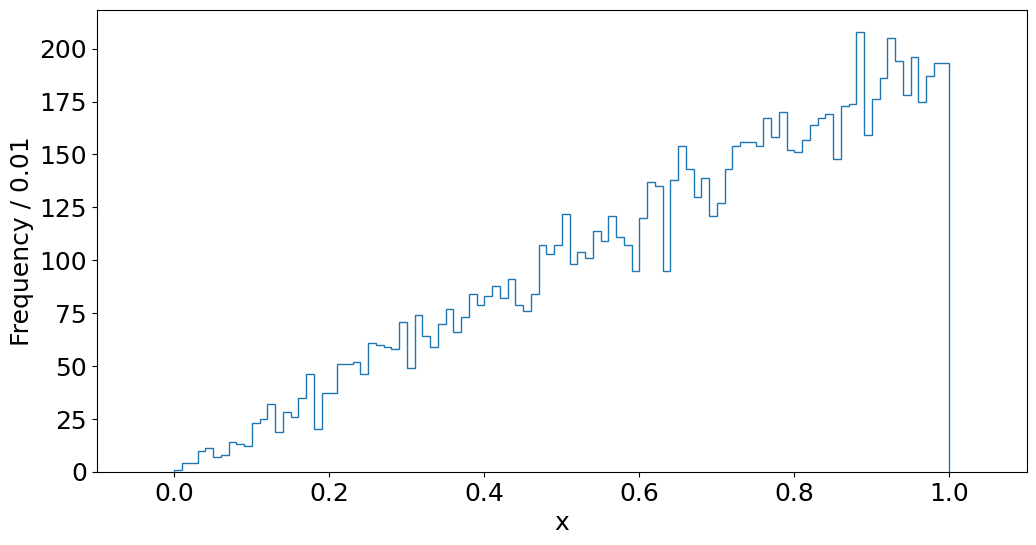

In [8]:
fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.hist(x_accepted, bins=N_bins, range=(xmin, xmax), histtype='step', label='histogram' )
ax2.set(xlabel="x", ylabel="Frequency / 0.01", xlim=(xmin-0.1, xmax+0.1));